# visualization timeseries
간단한 시각화와 날짜/시간 처리를 익힌다.
데이터를 빠르게 확인하고 흐름을 파악하는 용도로 사용한다.
(추후 Matplotlib에서 더 세밀한 시각화 방법을 학습한다.)

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# windows 기준 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 문제 방지
plt.rc('axes', unicode_minus=False)

## 선 그래프
- 시간의 흐름이나 순서에 따른 변화를 볼 때 자주 사용
- 월별 매출 추이처럼 증가/감소 흐름을 빠르게 확인 가능

Text(0, 0.5, '매출')

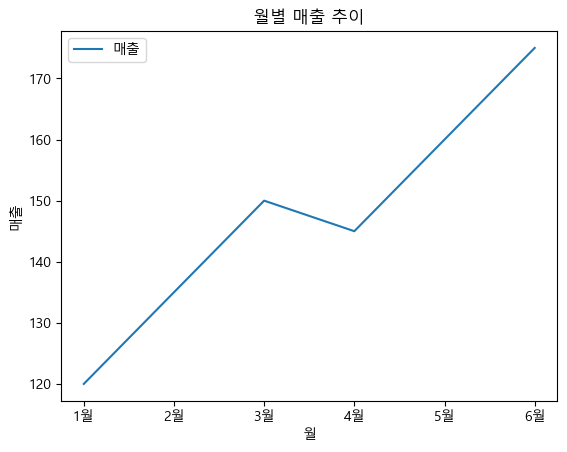

In [ ]:
sales = pd.DataFrame({
    '월' : ['1월','2월','3월','4월','5월','6월'],
    '매출' : [120,135,150,145,160,175]
})

# Pandas의 plot : 그래프의 기본 구조를 빠르개 생성 (단, 내부적으로 matplotlib 사용)
sales.plot(x='월', y='매출', kind='line', title='월별 매출 추이')

# matplotlib (plt) : 그래프의 세부 요소를 설정하는 역할
plt.ylabel('매출')

# show() : 현재까지 설정 된 그래프를 실제 화면에 출력
plt.show()

## 막대 그래프
- 항목 간 크기를 비교할 때 적합하다.
- 카테고리별 매출, 부서별 인원수 처럼 범주형 데이터를 비교할 때 자주 사용한다.

<Axes: xlabel='카테고리'>

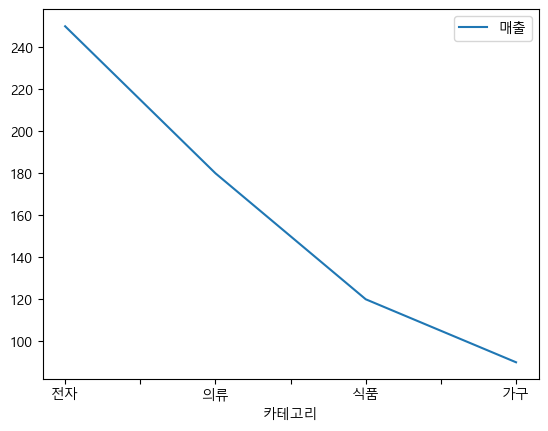

In [ ]:
category_sales = pd.DataFrame({
    '카테고리' : ['전자','의류','식품','가구'],
    '매출' : [250,180,120,90]
})

category_sales.plot(x='카테고리', y='매출', kind='bar', title='카테고리별 매출')

# x축의 글자 수평 표시
plt.xticks(rotation=0)



## 히스토그램
- 값이 어느 구간에 많이 몰려있는지 보는 그래프
- 점수, 나이, 가격처럼 연속형 데이터의 분포를 볼 때 사용한다.

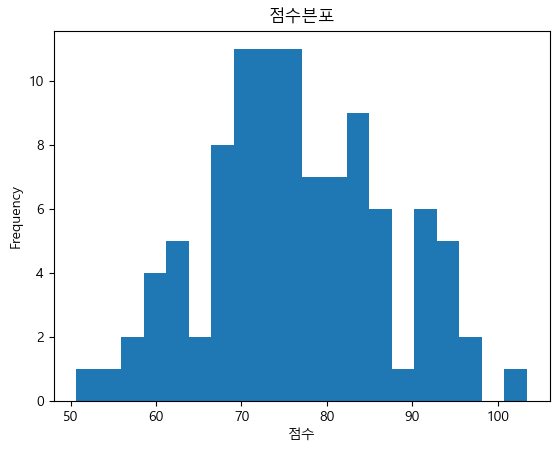

In [10]:
scores = pd.DataFrame({
    #np.random.normal(평균, 표준편차, 개수)
    '점수' : np.random.normal(75,10,100)
})

# bins : 구간을 몇 개로 나눌 것인지
scores['점수'].plot(kind='hist', bins=20, title='점수븐포')

plt.xlabel('점수')

plt.show()

## 파이 차트
- 전체에서 각 항목이 차지하는 비율을 볼 때 사용
- 시장 점유율처럼 비율을 한 눈에 볼때 적합

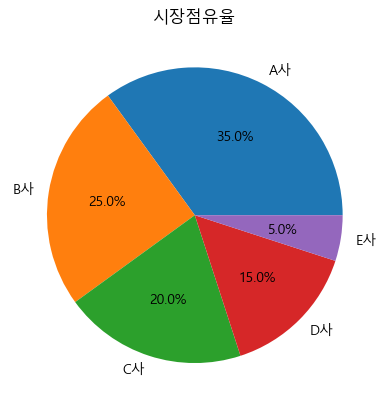

In [ ]:
market_share = pd.Series(
    [35,25,20,15,5], index=['A사','B사','C사','D사','E사']
)

market_share.plot(kind='pie',autopct='%.1f%%', title='시장점유율')

# 불필요한 y축 라벨 제거 (환경에 따라 다름)
plt.ylabel('')
plt.show()

## 산점도
- 두 수치형 변수 사이의 관계를 볼 때 사용
- 예를 들어 광고비가 증가할수록 매출도 늘어나는지? 와 같은 관계 확인

<Axes: title={'center': '광고비 vs 매출'}, xlabel='광고비', ylabel='매출'>

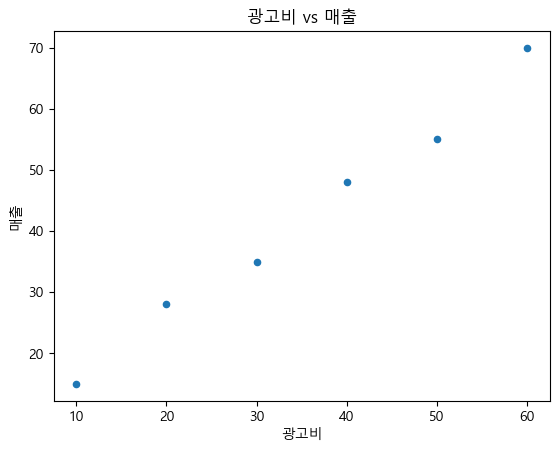

In [13]:
ad = pd.DataFrame({
    '광고비' : [10,20,30,40,50,60],
    '매출' : [15,28,35,48,55,70]
})

ad.plot(x='광고비', y= '매출', kind='scatter', title='광고비 vs 매출')

## 박스 플롯
- 분포, 중앙값, 이상치 여부를 빠르게 볼 수 있는 그래프
- 여러 집단의 분포를 비교할 때 유용하다

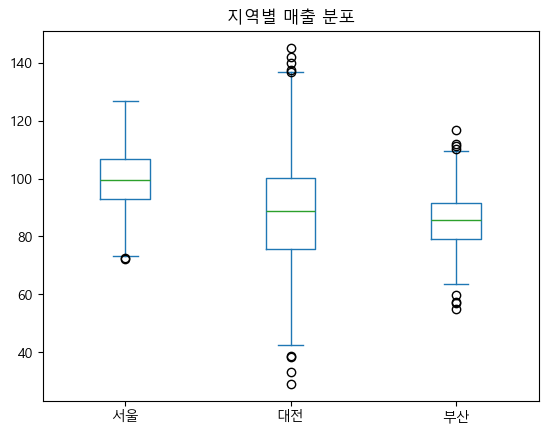

In [14]:
np.random.seed(0)
df_box = pd.DataFrame({
    # 비교적 높은 매출 + 적당한 변동
    '서울': np.random.normal(100,10,500) , 
    # 평균은 낮고 변동이 큼
    '대전': np.random.normal(90,20,500) , 
    # 평균은 낮지만 변동은 적음
    '부산': np.random.normal(85,10,500) , 
})

df_box.plot(kind='box', title='지역별 매출 분포')

plt.show()

## 날짜 타입 변환 
날짜가 문자열 상태이면 날짜 계산이나 시계열 기능을 제대로 사용할 수 없다.
그러므로 pd.to_datetime()으로 날짜형 변환을 먼저 수행해야 한다.

In [15]:
df = pd.DataFrame({
    '날짜' : ['2026-01-15', '2026-02-20', '2026-03-25'],
    '매출' : [100,120,130]
})

df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes


날짜    datetime64[us]
매출             int64
dtype: object

In [16]:
# 일정한 간격의 날짜 생성
pd.date_range(start='2026-01-01', periods=6, freq='ME')
pd.date_range(start='2026-01-01', periods=6, freq='MS')


DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[us]', freq='MS')

## 날짜 속성 추출
datetie 컬럼에서는 '.dt' 접근자를 통해 년, 월, 일, 요일 같은 날짜 속성을 쉽게 꺼낼 수 있다.
월별 집계, 요일별 분석 등에 사용 된다.

In [17]:
orders = pd.DataFrame({
    '주문일시' : pd.date_range('2026-01-01', periods=10,freq='D')
})

# 년, 월, 일, 요일 정보 추출
orders['년'] = orders['주문일시'].dt.year
orders['월'] = orders['주문일시'].dt.month
orders['일'] = orders['주문일시'].dt.day
orders['요일'] = orders['주문일시'].dt.dayofweek
orders['요일명'] = orders['주문일시'].dt.day_name()

orders

,주문일시,년,월,일,요일,요일명
0,2026-01-01,2026,1,1,3,Thursday
1,2026-01-02,2026,1,2,4,Friday
2,2026-01-03,2026,1,3,5,Saturday
3,2026-01-04,2026,1,4,6,Sunday
4,2026-01-05,2026,1,5,0,Monday
5,2026-01-06,2026,1,6,1,Tuesday
6,2026-01-07,2026,1,7,2,Wednesday
7,2026-01-08,2026,1,8,3,Thursday
8,2026-01-09,2026,1,9,4,Friday
9,2026-01-10,2026,1,10,5,Saturday


## 날짜 인덱스
날짜를 인덱스로 두면 날짜 범위 슬라이싱이 편해진다.

In [ ]:
sales_ts = pd.DataFrame({
    '날짜' : pd.date_range('2026-01-01', periods=100, freq='D'),
    '매출' : range(100,200)
}).sort_index('날짜')

sales_ts.head()

AttributeError: 'dict' object has no attribute 'sort_index'

In [19]:
# 날짜 범위 슬라이싱
sales_ts['2026-01-15': '2026-01-20']

NameError: name 'sales_ts' is not defined

In [ ]:
# 특정 월 선택
sales_ts.loc['2026-02'].head()

## 리샘플링 
시계열 데이터를 다른 시간 단위로 다시 묶는 작업이다.
일별 데이터를 월별, 주별 데이터로 요약할 때 많이 사용한다.

In [ ]:
# 일별 매출 데이터 생성
daily_sales = pd.DataFrame({
    '매출' : range(1,91)
}, index=pd.date_range('2026-01-01', periods=90, freq='D'))

daily_sales.resample('ME').sum()

In [ ]:
# 주변 평균
daily_sales.resample('W').mean()

## 이동 평균
이동 평균은 최근 n개 값의 평균을 구해 짧은 변동을 줄이고 전체 흐름을 더 부드럽게 보는 방법이다.

In [21]:
# 일별 매출 추이 데이터
trend = pd.DataFrame({
    '매출' : [100,120,90,130,110,140,95,150,120,160]
},index=pd.date_range('2026-01-01', periods=10,freq='D'))

# rolling : 최근 n개 구간 기준 계산 
trend['이동평균_3일'] = trend['매출'].rolling(3).mean()
trend['이동평균_5일'] = trend['매출'].rolling(5).mean()

trend

,매출,이동평균_3일,이동평균_5일
2026-01-01,100,NaN,NaN
2026-01-02,120,NaN,NaN
2026-01-03,90,103.333333,NaN
2026-01-04,130,113.333333,NaN
2026-01-05,110,110.000000,110.0
2026-01-06,140,126.666667,118.0
2026-01-07,95,115.000000,113.0
2026-01-08,150,128.333333,125.0
2026-01-09,120,121.666667,123.0
2026-01-10,160,143.333333,133.0


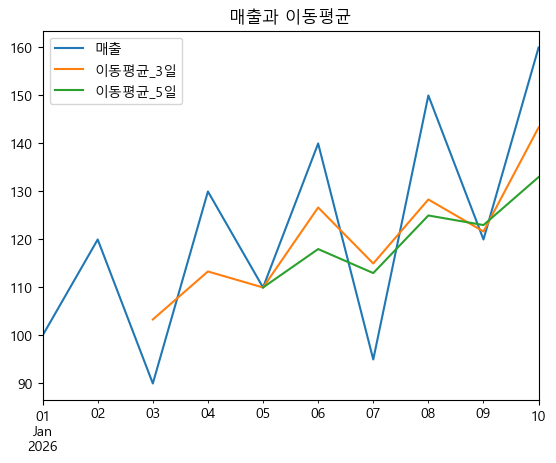

In [22]:
# 매출과 이동 평균 시각화
trend[['매출','이동평균_3일','이동평균_5일']].plot(title='매출과 이동평균')
plt.show()

## shift / diff/ pct_change
시계열에서는 이전 값과 비교하는 작업이 자주 나온다.

In [25]:
compare = pd.DataFrame({
    '매출' : [100,110,105,120,115]
}, index=pd.date_range('2026-01-01', periods=5,freq='D'))

compare['전일매출'] = compare['매출'].shift(1)  # 이전 값 밀어오기
compare['전일대비'] = compare['매출'].diff()  # 이전 값과의 차이
compare['변화율'] = compare['매출'].pct_change()*100  # 이전 값 대비 변화율

compare

,매출,전일매출,전일대비,변화율
2026-01-01,100,NaN,NaN,NaN
2026-01-02,110,100.0,10.0,10.000000
2026-01-03,105,110.0,-5.0,-4.545455
2026-01-04,120,105.0,15.0,14.285714
2026-01-05,115,120.0,-5.0,-4.166667


## 시계열 시각화
시계열 데이터는 원본 값만 보면 변동이 심해서 흐름이 잘 안 보일 수 있다.
따라서 이동 평균과 함께 그러면 전체 추세를 더 쉽게 파악할 수 있다.
또한 리샘플링 후 집계처럼 더 큰 단위로 요약해서 볼 수도 있다.

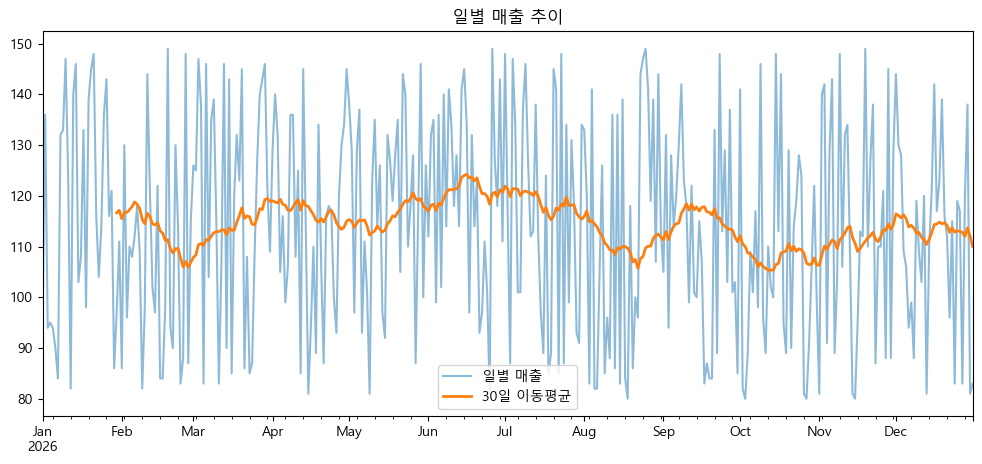

In [27]:
# 1년치 일별 매출 데이터 생성
year_sales = pd.DataFrame({
    '매출' : np.random.randint(80,150,365)
}, index=pd.date_range('2026-01-01',periods=365, freq='D'))


# 30일 이동평균 계산
year_sales['이동평균'] = year_sales['매출'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12,5))

year_sales['매출'].plot(ax=ax,alpha=0.5, label='일별 매출')   # alpha : 투명도
year_sales['이동평균'].plot(ax=ax,linewidth=2, label='30일 이동평균') # linewidth : 두께

plt.title('일별 매출 추이')
plt.legend()       # 라벨 지정 이름 출력
plt.show()

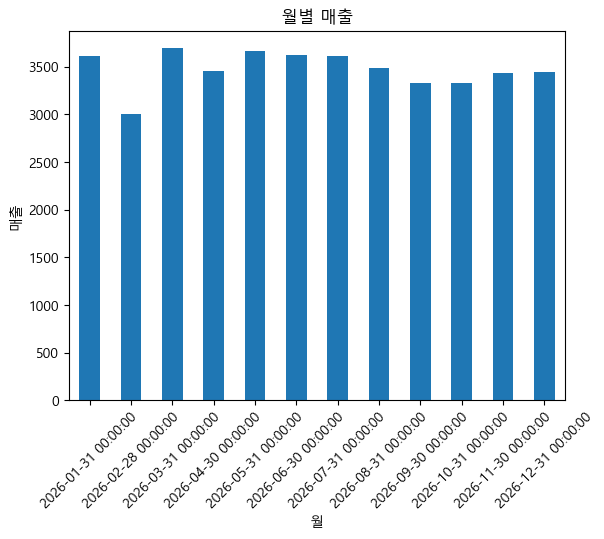

In [28]:
# 월별 집계 후 막대 그래프
monthly = year_sales.resample('ME')['매출'].sum()

monthly.plot(kind='bar', title='월별 매출')

plt.xlabel('월')
plt.ylabel('매출')

plt.xticks(rotation=45)

plt.show()